<a href="https://colab.research.google.com/github/lordoffatcats/TOL403G/blob/notebooks/T%C3%96L403G_Lokaverkefni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.2. Reiknirit
Útfærið reiknirit sem finnur stystu leið milli tveggja punkta með tilliti til vegalengdar, notið upplýsingar um vegalengd og hraða til að meta tímann. Einfaldasta leiðin til að leysa þetta er að nota reiknirit Dijkstra og fara síðan í aðrar útvíkkanir s.s. $A^\star$.

Þegar hlaða þarf bíl þarf að finna stystu leið í vegalengd sem tekur tillit til þess að á rafbílum er mögulega ekki hægt að fara alla leið á einni hleðslu. Þá þarf að módelera verkefnið sem stystu leið í mun stærra neti.

---
---

# 2.3.1. Innlestur á gögnum
Lesið inn netið úr skránum sem eru gefnar, `nodes.tsv` og edges.tsv. Í skránni `nodes.tsv` eru hnútar með auðkenni $(id)$, hnit $(x, y)$ og lengdar og breiddargráður. Í skránni `edges.tsv` eru leggi frá hnúti u til hnúts v með lengd length, mæld í metrum, nafn $(name)$ og hámarkshraða.

---

Hér eru gögnin `(.tsv skrárnar)` lesnar inn, og breytt í form sem hægt er að vinna með í python.

In [33]:
import pandas as pd
!git clone https://github.com/lordoffatcats/TOL403G.git

fatal: destination path 'TOL403G' already exists and is not an empty directory.


Inntakið er stefnt net af Íslandi, hver hnútur $v$ táknar mót tveggja vega og hefur auðkenni og staðsetningu, $(x, y)$ hnit og breiddar- og lengdargráður ($x, y$ hnitin eru betri upp á að teikna gögnin og reikna fjarlægð (í metrum) en lat/lon til að bera saman við úttak úr t.d. Google maps).

Leggirnir $(u, v)$ tákna vegi, þ.e. það er hægt að keyra á frá $u$ til $v$ og á milli þessara hnúta er ekki hægt að taka neinar aðrar ákvarðanir í umferðinni.

Skráin `nodes.tsv` inniheldur upplýsingar um hnútana, `edges.tsv` inniheldur upplýsingar
um vegina.

## 1. Innlestur gagna með Pandas

In [34]:
nodes = pd.read_table('TOL403G/nodes.tsv')
edges = pd.read_table('TOL403G/edges.tsv')
charging = pd.read_table('TOL403G/charging.tsv')

In [35]:
# Sanity check
display(nodes)
display(edges)
#display(charging)

,id,x,y,lon,lat
0,0,347455.398,395070.736,-22.121370,64.024982
1,1,356654.934,399349.526,-21.937473,64.067271
2,2,349659.775,396020.416,-22.077281,64.034459
3,3,356636.442,399349.091,-21.937852,64.067260
4,4,356624.272,399325.852,-21.938078,64.067047
...,...,...,...,...,...
2761,2761,331946.284,380009.471,-22.421461,63.882871
2762,2762,331916.386,379952.497,-22.422006,63.882346
2763,2763,731016.264,513302.256,-14.090579,65.038817
2764,2764,731085.667,513289.028,-14.089132,65.038650


,u,v,length,name,highway,maxspeed_kph,oneway
0,0,2682,1948.768,Reykjanesbraut,trunk,90.0,1
1,1,3,18.992,Hlíðartorg,trunk,60.0,1
2,1,1658,653.666,Reykjanesbraut,trunk,60.0,1
3,2,1801,423.640,Reykjanesbraut,trunk,90.0,1
4,2,2678,208.144,NaN,trunk_link,50.0,1
...,...,...,...,...,...,...,...
4998,2763,558,2054.392,Norðfjarðarvegur,primary,90.0,0
4999,2763,2764,77.272,NaN,primary_link,NaN,1
5000,2765,558,60.781,Norðfjarðarvegur,primary,90.0,0
5001,2765,2483,3684.807,Austurvegur|Norðfjarðarvegur,primary,70.0,0


## 2. Uppsetning á neti
Byrjum á að setja upp netið sem grannalista á forminu:

```yaml
hnútur1: [(granni1, þyngd), (granni2, þyngd), ...],
hnútur2: ...,
...
```

*(Við notum grannalista frekar en Grannafylki því að tímaflækja Dijkstra með fylki er $\mathcal{O}(|V|^2)$, en með lista fæst $\mathcal{O}(|E|\log |V|)$)*

In [36]:
net = {node_id: [] for node_id in nodes["id"]}

for u, v, w, oneway in zip(
    edges["u"], edges["v"], edges["length"], edges["oneway"]
):
    net[u].append((v, w))
    if not oneway:
        net[v].append((u, w))

# sanity check
for i in range(10):
    print(net[i])

[(2682, 1948.768)]
[(3, 18.992), (1658, 653.666)]
[(1801, 423.64), (2678, 208.144)]
[(12, 8.737)]
[(10, 14.669)]
[(550, 242.714), (14, 27.836)]
[(1947, 245.206), (1946, 186.31)]
[(1237, 2896.73)]
[(2046, 233.096), (0, 483.358)]
[(1241, 257.243), (7, 482.499)]


# 2.3.2. Reiknirit Dijkstra
[A Note on Two Problems in Connexion with Graphs](https://ir.cwi.nl/pub/9256/9256D.pdf)

Útfærum reiknirit Dijkstra sem tekur inn tvo hnúta og finnur stystu leið milli tveggja hnúta.

Reiknirit Dijkstra er eftirfarandi:

1. Búum til mengi af öllum óheimsóttum hnútum.
2. Gefum hverjum hnút upphafsfjarlægð frá byrjunarhnút. $0$ fyrir upphafshnútinn og $\infty$ fyrir alla hina, þar sem við þekkjum ekki neina leið að þeim.
3. Veljum hnútinn úr óheimsótta menginu, sem hefur lægstu endanlegu fjarlægð. Í upphafi verður þetta upphafshnúturinn. Ef mengið er tómt eða allir hnútar hafa $\infty$ fjarlægð, þá stoppum við og förum í skref 6. Ef markmiðið er eingöngu leiðin að ákveðnum hnút $v$ stoppum við þegar valdi hnúturinn er $v$. Annars, þá höldum við áfram.
4. Fyrir valda hnútinn $u_i$, þá skoðum við alla óheimsótta nágranna hans og uppfærum fjarlægðir útfrá $u_i$. Þ.e. ef fjarlægðin að nágranna er styttri frá $u_i$, þá breytum við fjarlægðinni í þá lægri.
5. Eftir að allir óheimsóttir nágrannar $u_i$ eru uppfærðir, þá er $u_i$ fjarlægður úr óheimsótta menginu.
6. Þegar lykkjunni í skrefum 3-5 er lokið, þá innihalda allir heimsóttir hnútar stystu vegalengd frá byrjunarhnút.

Við útfærum mengið af óheimsóttum hnútum sem min-hrúgu með `heapq`, þar sem lyklarnir eru fjarlægðirnar og gildin eru hnútar.

In [37]:
from os import path
import heapq

def Dijkstra(G, start, end=None):
    """ Notar reiknirit Dijkstra til að finna stystu leið milli tveggja hnúta.
    Inntak:
        G: Net táknað sem grannalisti. Á forminu Dict[int, List[Tuple[int, float]]].
        start: id á upphafshnút í netinu
        end: id á endahnút í netinu.
    Úttak:
        fjalaegdir: Dict sem inniheldur fjarlægðir frá start að hnútum í netinu, þar til leið að end var fundin. Ef end=None er fjarlægð að öllum hnútum reiknuð.
        SPT: Dict sem heldur utan um Shortest Path Tree.

    """
    fjarlaegdir = {node: float("inf") for node in G}
    fjarlaegdir[start] = 0.0
    SPT = {node: None for node in G} # fyrir rakningu á leið milli start og end hnúta

    heap = [(0.0, start)]

    while heap:
        current_dist, u = heapq.heappop(heap)

        if u == end: # stoppum þegar valdi hnúturinn er endahnúturinn
            break

        if current_dist > fjarlaegdir[u]:
            continue

        for v, weight in G[u]:
            new_dist = current_dist + weight

            if new_dist < fjarlaegdir[v]:
                fjarlaegdir[v] = new_dist
                SPT[v] = u
                heapq.heappush(heap, (new_dist, v))
            #if end != None: # Stoppum þegar við erum komin á endahnút
                #if v == end:
                    #break
    return fjarlaegdir, SPT

def rekja_leid(SPT, start, end):
    """ Rekur stystu leið milli tveggja hnúta, gefið að reiknirit Dijkstra hafi verið notað á netið.
    Inntak:
        SPT: Dict sem heldur utan um Shortest Path Tree.
        start: id á upphafshnút
        end: id á endahnút
    Úttak:
        Listi af hnútum á milli start og end sem táknar stysta vega þar á milli.
    """
    leid = []
    v = end

    while v is not None:
        leid.append(v)
        v = SPT[v]
    leid.reverse()

    if leid and leid[0] == start:
        return leid
    return []

# 2.3.3. Framsetning
Sýnið leið milli 5 para af hnútum af ólíkri lengd, fyrir ca 5,10,50,100 og 400 km langar vegalengdir. Teiknið upp leiðirnar með því að nota hnitin á hnútunum. Tékkið ykkur af með því að bera saman leiðina sem er fundin og fjarlægðina miðað við kortavefi eins og t.d. Google Maps.

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # fallback
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
})




def plot_graph(nodes_df, edges_df, path=None, lon_min=-90.0, lat_min=-90.0, lon_max=90.0, lat_max=90.0):
    """ Teiknar mynd af neti og (mögulega) veg á skilgreindu svæði í kortahnitum.
    Inntak:
        nodes_df: Pandas dataframe sem inniheldur upplýsingar um hnúta í netinu.
        edges_df: Pandas dataframe sem inniheldur upplýsingar um leggi í netinu.
        path: Listi af hnútum (id-um) sem mynda vega sem skal teikna.
        lon_min: Neðri mörk x hnita sem skal teikna.
        lat_min: Neðri mörk y hnita sem skal teikna.
        lon_max: Efri mörk x hnita sem skal teikna.
        lat_max: Efri mörk y hnita sem skal teikna.
    Ísland er ca á longitude [-25, -13] og latitude [63-67]
    """
    # filtera hnúta og leggi fyrir staðsetningu
    #nodes_df = nodes_df[(nodes_df['lat'] >= lat_min) & (nodes_df['lat'] <= lat_max)]
    #nodes_df = nodes_df[(nodes_df['lon'] >= lon_min) & (nodes_df['lon'] <= lon_max)]
    #edges_df = edges_df[
    #    (edges_df['u']).isin(nodes_df['id'])
    #     & ((edges_df['v']).isin(nodes_df['id']))
    #]

    # lookup tafla frá id -> (lat, lon)
    node_pos = nodes_df.set_index('id')[['lon', 'lat']].to_dict('index')

    # teikna hnútana
    fig, ax = plt.subplots()
    ax.scatter(nodes_df['lon'], nodes_df['lat'], s=2)

    # teikna leggina
    for _, row in edges_df.iterrows():
        u, v = row['u'], row['v']

        if u in node_pos and v in node_pos:
            x = [node_pos[u]['lon'], node_pos[v]['lon']]
            y = [node_pos[u]['lat'], node_pos[v]['lat']]
            ax.plot(x, y, color='grey', linewidth=0.5)

    # teikna veg
    if path:
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            if u in node_pos and v in node_pos:
                x = [node_pos[u]['lon'], node_pos[v]['lon']]
                y = [node_pos[u]['lat'], node_pos[v]['lat']]
                ax.plot(x, y, color='red', linewidth=2)

    ax.tick_params(labelsize=10)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.xaxis.set_major_formatter(
        mticker.FormatStrFormatter(r"$%.1f$")
    )
    ax.yaxis.set_major_formatter(
        mticker.FormatStrFormatter(r"$%.1f$")
    )
    ax.set_xlabel(r"$\mathrm{Longitude}$")
    ax.set_ylabel(r"$\mathrm{Latitude}$")
    plt.show

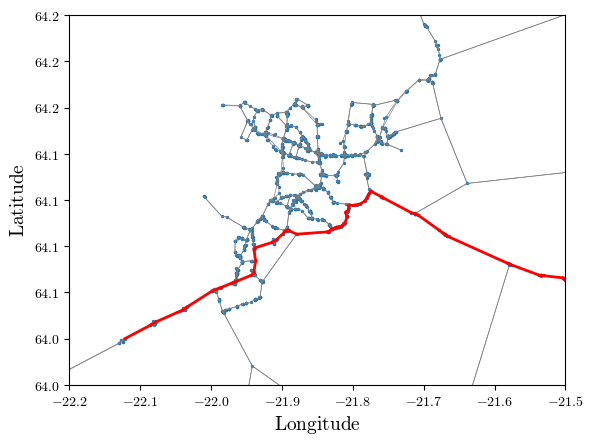

In [45]:
l = rekja_leid((Dijkstra(net,0,20)[1]), 0, 20)
plot_graph(nodes, edges, l, -22.2, 64, -21.5, 64.2)

# 2.3.4. Leiðarvísir
Takið stystu leið og búið til leiðarvísir, athugið að fjöldi hnúta verður mun meiri en fjöldi
það sem við myndum sýna notendum. ***(Hvað er átt við nákvæmlega með leiðarvísi?)***

# 2.3.5. Tímamælingar
Mælið tímann sem reikniritið dijkstra tekur að reikna fjarlægðir milli hnúta og hversu margir
hnútar eru skoðaðir fyrir þau fimm pör sem voru valin.

# 2.3.6.. $A^\star$ reikniritið
[A Formal Basis for the Heuristic Determination of Minimum Cost Paths](https://www.cs.auckland.ac.nz/courses/compsci709s2c/resources/Mike.d/astarNilsson.pdf)

Útfærið $A^\star$ reikniritið sem tekur inn lista af lokahnútum og reiknar fjarlægðir frá öllum hnútum í netinu. Sem neðra mat á fjarlægð á milli hnútanna má taka beina loftlínu milli punktanna. Mælið tíma og berið saman við reiknirit Dijkstra fyrir leiðir lengri en 50km, teiknið upp mynd af þeim hnútum sem voru skoðaðir.

In [39]:
import numpy as np

node_pos = nodes.set_index('id')[['lon', 'lat']].to_dict('index') # dict fyrir staðsetningu hnúta

def cartesian_norm(u, v):
    """ Reiknar Kartesíska lengd milli tveggja hnúta.
    Inntak:
        u,v: hnútar sem reikna skal fjarlægð á milli.
    Úttak: Fjarlægð milli hnúta u og v.
    """
    u_lon = node_pos[u]['lon']
    u_lat = node_pos[u]['lat']
    v_lon = node_pos[v]['lon']
    v_lat = node_pos[v]['lat']
    return np.sqrt((u_lon-v_lon)**2 + (u_lat-v_lat)**2)

#print(cartesian_norm(10,11)) # sanity check

def A_star(G, start, end=None, h=cartesian_norm):
    """ Notar A* til að finna stystu leið milli tveggja hnúta.
    Inntak:
        G: Net táknað sem grannalisti. Á forminu Dict[int, List[Tuple[int, float]]].
        start: id á upphafshnút í netinu
        end: id á endahnút í netinu.
        h: Heuristískt nálgunarfall á raunfjarlægð milli tveggja hnúta.
    Úttak:
        fjalaegdir: Dict sem inniheldur fjarlægðir frá start að hnútum í netinu, þar til leið að end var fundin. Ef end=None er fjarlægð að öllum hnútum reiknuð.
        SPT: Dict sem heldur utan um Shortest Path Tree.
    """
    # rétt fjarlægð
    g_score = {node: float("inf") for node in G}
    g_score[start] = 0.0

    #f_score[n] = g_score[n] + h(start, n)
    f_score = {node: float("inf") for node in G}
    f_score[start] = h(start, start) # 0?

    SPT = {node: None for node in G} # fyrir rakningu á leið milli start og end hnúta

    heap = [(0.0, start)]

    while heap:
        current_dist, u = heapq.heappop(heap)

        if u == end: # stoppum þegar valdi hnúturinn er endahnúturinn
            break

        #if current_dist > fjarlaegdir[u]:
            #continue

        for v, weight in G[u]:
            new_g_score = current_dist + weight

            if new_g_score < g_score[v]:
                SPT[v] = u
                g_score[v] = new_g_score
                f_score[v] = new_g_score + h(start, v)
                heapq.heappush(heap, (f_score[v], v))
    return g_score, SPT

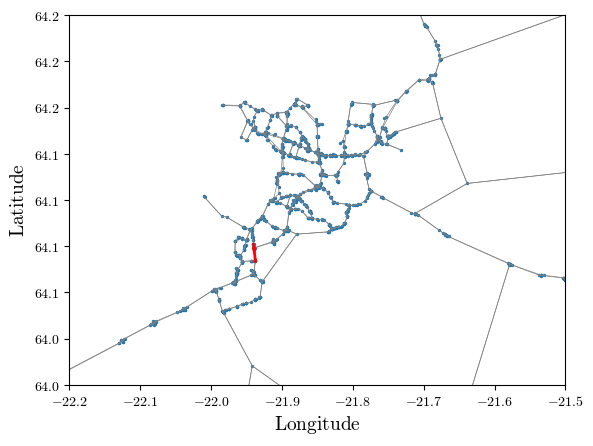

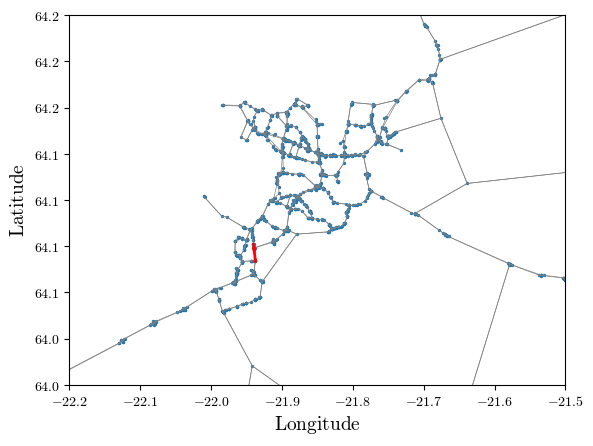

In [43]:
start = 10
end = 14
l1 = rekja_leid((Dijkstra(net,start,end)[1]), start, end)
l2 = rekja_leid((A_star(net,start,end)[1]), start, end)
plot_graph(nodes, edges, l1, -22.2, 64, -21.5, 64.2)
plot_graph(nodes, edges, l2, -22.2, 64, -21.5, 64.2)

# 2.3.7. Hleðslustöðvar

- Í skránni `charging.tsv` er listi yfir hleðslustöðvar. Í þessu verkefni á að vinna stystu
vegalengd fyrir lengri sem þarf mögulega að hlaða rafbílinn. ***(Veit ekki hvað í andskotanum þetta þýðir)***
- Reikniritið tekur inn upphafshleðslu og lámarkshleðslu á lokastað.
-  Finnið stystu vegalengd fyrir fullhlaðinn bíl sem keyrir frá Reykjavík til Akureyrar, annars vegar með 80Khw og 40Khw batteríi.
- Finnið gögn fyrir eyðslu per km og stækkið netið með því að halda utan um hleðsluna á hverri staðsetningu, þ.e. fyrir hvern hnút $v$ í upprunalega netinu þarf að búa til hnútana $(v,w)$ þar sem $w$ er hleðslan á bílnum, ***(Veit ekki hvað þetta þýðir)***
- ef við erum með legg $(u,v)$ í upprunalega netinu þá tengjum við saman hnútana $((u, w), (v, w −\Delta w))$ þar sem $\Delta w$ er orkan sem þarf til að keyra á milli hnútanna í upprunalega netinu.
- Á hleðsluhnútum er hægt að auka við orkuna, þ.e. tengja á milli $(v, w)$ og $(v, w′)$. Hversu marga nýja hnúta þarf að setja inn til að fá nothæfa lausn? ***(Hvað er ***$w'$***)***

# 2.3.8. Nákvæm lausn á hleðslu
Finnið stysta tíma með hleðslu en takið inn í myndina að hleðslustöðvarnar eru misgóðar og taka mislangan tíma að hlaða. Finnið stystu leið frá Reykjavík til Ísafjarðar. Búið ekki til allt stóra netið fyrirfram heldur haldið eingöngu utan um þá hnúta sem eru kannaðir með reikniritum Dijkstra eða $A^\star$.